# Importing Necessary Libraries

In order to successfully build a classification model for prediction of Parkinson's Disease, we will need to import the following libraries:
- Pandas for handling datasets.
- NumPy for numerical operations.
- Matplotlib for data visualization
- Seaborn for data visualization
- Sklearn for data preprocessing, model training, and evaluation.
- XGBoost for high-performance machine learning classification.
- Imblearn to handle imbalanced data.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

# Loading the Dataset

We will load the dataset as a Pandas DataFrame, and store it in the variable `df`. We shall explore its first five rows using the `head()` method.

In [3]:
df = pd.read_csv("parkinson_disease.csv")

# Display the first five rows of the DataFrame
df.head()

,id,gender,PPE,DFA,RPDE,numPulses,numPeriodsPulses,meanPeriodPulses,stdDevPeriodPulses,locPctJitter,...,tqwt_kurtosisValue_dec_28,tqwt_kurtosisValue_dec_29,tqwt_kurtosisValue_dec_30,tqwt_kurtosisValue_dec_31,tqwt_kurtosisValue_dec_32,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
0,0,1,0.85247,0.71826,0.57227,240,239,0.008064,0.000087,0.00218,...,1.5620,2.6445,3.8686,4.2105,5.1221,4.4625,2.6202,3.0004,18.9405,1
1,0,1,0.76686,0.69481,0.53966,234,233,0.008258,0.000073,0.00195,...,1.5589,3.6107,23.5155,14.1962,11.0261,9.5082,6.5245,6.3431,45.1780,1
2,0,1,0.85083,0.67604,0.58982,232,231,0.008340,0.000060,0.00176,...,1.5643,2.3308,9.4959,10.7458,11.0177,4.8066,2.9199,3.1495,4.7666,1
3,1,0,0.41121,0.79672,0.59257,178,177,0.010858,0.000183,0.00419,...,3.7805,3.5664,5.2558,14.0403,4.2235,4.6857,4.8460,6.2650,4.0603,1
4,1,0,0.32790,0.79782,0.53028,236,235,0.008162,0.002669,0.00535,...,6.1727,5.8416,6.0805,5.7621,7.7817,11.6891,8.2103,5.0559,6.1164,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Columns: 755 entries, id to class
dtypes: float64(749), int64(6)
memory usage: 4.4 MB


In [5]:
# checking for null values in df
df.isnull().sum()

id                           0
gender                       0
PPE                          0
DFA                          0
RPDE                         0
                            ..
tqwt_kurtosisValue_dec_33    0
tqwt_kurtosisValue_dec_34    0
tqwt_kurtosisValue_dec_35    0
tqwt_kurtosisValue_dec_36    0
class                        0
Length: 755, dtype: int64

Since there are no missing or null values in the dataset, we can proceed with scaling the numeric features which will result in better performance of the model.

# Data Preprocessing

Before scaling, let us separate the features (X) from the target (y). The target, in this case, is the `class` column, and the remaining columns act as features.

In [6]:
# separating the target from the rest of the features of the training dataset
X, y = df.drop(['class'], axis=1), df['class']

X.shape, y.shape

((756, 754), (756,))

In [7]:
# Checking for categorical features
X.select_dtypes(exclude='number')

""
0
1
2
3
4
...
751
752
753
754


Since there are no categorical features, we do not need to do any encoding.

In [8]:
X.id.value_counts()

id
0      3
1      3
2      3
3      3
4      3
      ..
247    3
248    3
249    3
250    3
251    3
Name: count, Length: 252, dtype: int64

Since `id` column does not have unique values for each distinct row, i.e. the values are repeated at times for multiple rows, we cannot exclude the `id` column as it can be an important feature that will influence the classification model.

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = X.copy()

# List of columns to scale
scaled_columns = list(X.drop(['id', 'gender'], axis=1).columns)

# Fit on training data and transform both training and test data
X[scaled_columns] = scaler.fit_transform(X[scaled_columns])

In [10]:
y.value_counts()

class
1    564
0    192
Name: count, dtype: int64

In [11]:
total = y.value_counts()[1] + y.value_counts()[0]

y.value_counts()[1]/total, y.value_counts()[0]/total

(np.float64(0.746031746031746), np.float64(0.25396825396825395))

Clearly, about 74.6% of the data has class label 1, and the remaining has class label 0. This is indicative that the dataset could be imbalanced. To further check for imbalance, let us visualize the data with scatter plots.

Counter({1: 564, 0: 192})


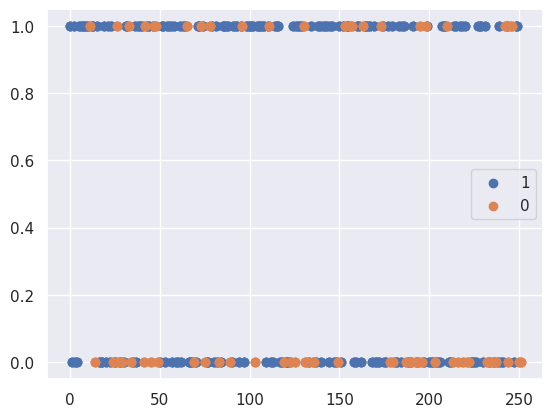

In [12]:
from collections import Counter
# summarize class distribution
counter = Counter(y)
print(counter)
# scatter plot of examples by class label
for label, _ in counter.items():
	row_ix = np.where(y == label)[0]
	plt.scatter(X.to_numpy()[row_ix, 0], X.to_numpy()[row_ix, 1], label=str(label))
plt.legend()
plt.show()

Counter({1: 564, 0: 564})


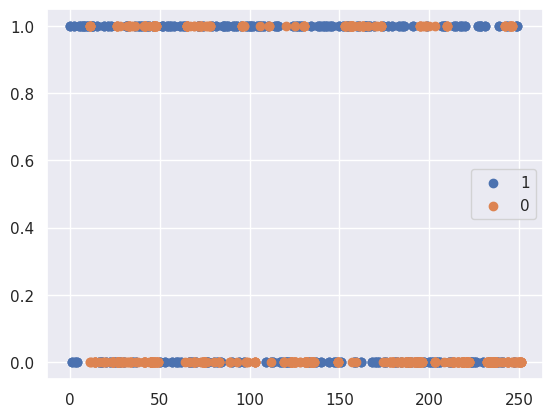

In [13]:
# importing APIs for SMOTE
from imblearn.over_sampling import SMOTE
# transform the dataset
oversample = SMOTE()
X, y = oversample.fit_resample(X, y)
# summarize the new class distribution
counter = Counter(y)
print(counter)
# scatter plot of examples by class label
for label, _ in counter.items():
	row_ix = np.where(y == label)[0]
	plt.scatter(X.to_numpy()[row_ix, 0], X.to_numpy()[row_ix, 1], label=str(label))
plt.legend()
plt.show()

# Splitting the Dataset

In order to avoid data snooping bias, we will have to split our dataset before training our dataset with any machine learning model. We shall split the dataset into training and test datasets such that the training and test datasets contain 80% and 20% of the total dataset respectively.

Now that we have separated the features from the target, we can split the dataset into training and test dataset in the 80:20 ratio as mentioned above.

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((902, 754), (226, 754), (902,), (226,))

# Exploratory Data Analysis (EDA)

In [15]:
# Creating a DataFrame for EDA
df_eda = X.copy()
df_eda['target'] = y
df_eda.head()

,id,gender,PPE,DFA,RPDE,numPulses,numPeriodsPulses,meanPeriodPulses,stdDevPeriodPulses,locPctJitter,...,tqwt_kurtosisValue_dec_28,tqwt_kurtosisValue_dec_29,tqwt_kurtosisValue_dec_30,tqwt_kurtosisValue_dec_31,tqwt_kurtosisValue_dec_32,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,target
0,0,1,0.627644,0.256144,0.605835,-0.846892,-0.842373,0.933328,-0.407251,-0.054993,...,-0.584822,-0.619412,-0.576762,-0.482286,-0.399331,-0.484533,-0.775137,-0.814727,-0.366595,1
1,0,1,0.121620,-0.080433,0.368415,-0.907404,-0.902773,1.040014,-0.426092,-0.142570,...,-0.584895,-0.589778,0.193084,0.016183,-0.067120,-0.175566,-0.526647,-0.582972,0.400396,1
2,0,1,0.617950,-0.349839,0.733609,-0.927575,-0.922907,1.084576,-0.443557,-0.214916,...,-0.584767,-0.629033,-0.356261,-0.156055,-0.067593,-0.463462,-0.756063,-0.804390,-0.780935,1
3,1,0,-1.980560,1.382279,0.753631,-1.472186,-1.466513,2.464215,-0.275316,0.710353,...,-0.532242,-0.591137,-0.522406,0.008400,-0.449894,-0.470865,-0.633475,-0.588387,-0.801583,1
4,1,0,-2.472989,1.398068,0.300123,-0.887233,-0.882640,0.987044,3.143597,1.152045,...,-0.475545,-0.521356,-0.490090,-0.404833,-0.249678,-0.042021,-0.419354,-0.672216,-0.741477,1


In [16]:
# Extracting the numeric columns for EDA 
num_cols = df_eda.select_dtypes(include=np.number).columns
# Too many numeric features, so plotting a few at a time
plot_features = num_cols[:6]
plot_features_list = plot_features.tolist()
if 'gender' in plot_features:
    plot_features_list.remove('gender')

## Histogram

We will plot a histogram for some of the numeric features to see their underlying distribuiton and skewness.

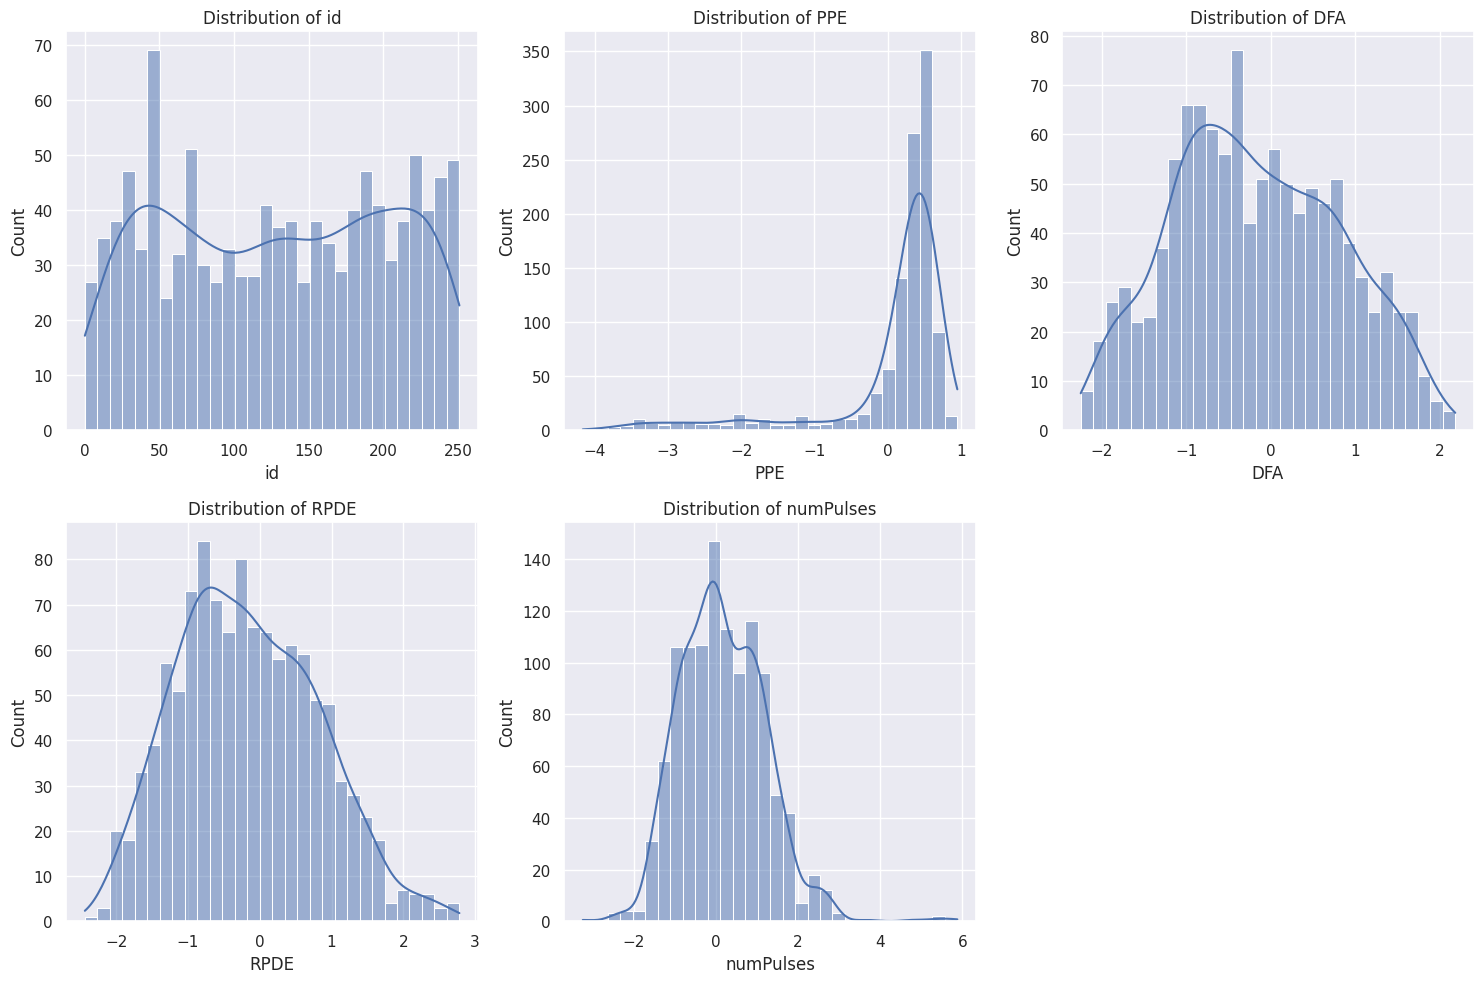

In [17]:
plt.figure(figsize=(15, 10))
for i, feature in enumerate(plot_features_list):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df_eda[feature], kde=True, bins=30)
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

## Boxplot

Boxplot helps us visualize the quartiles of the data, as well as plots outliers if any.

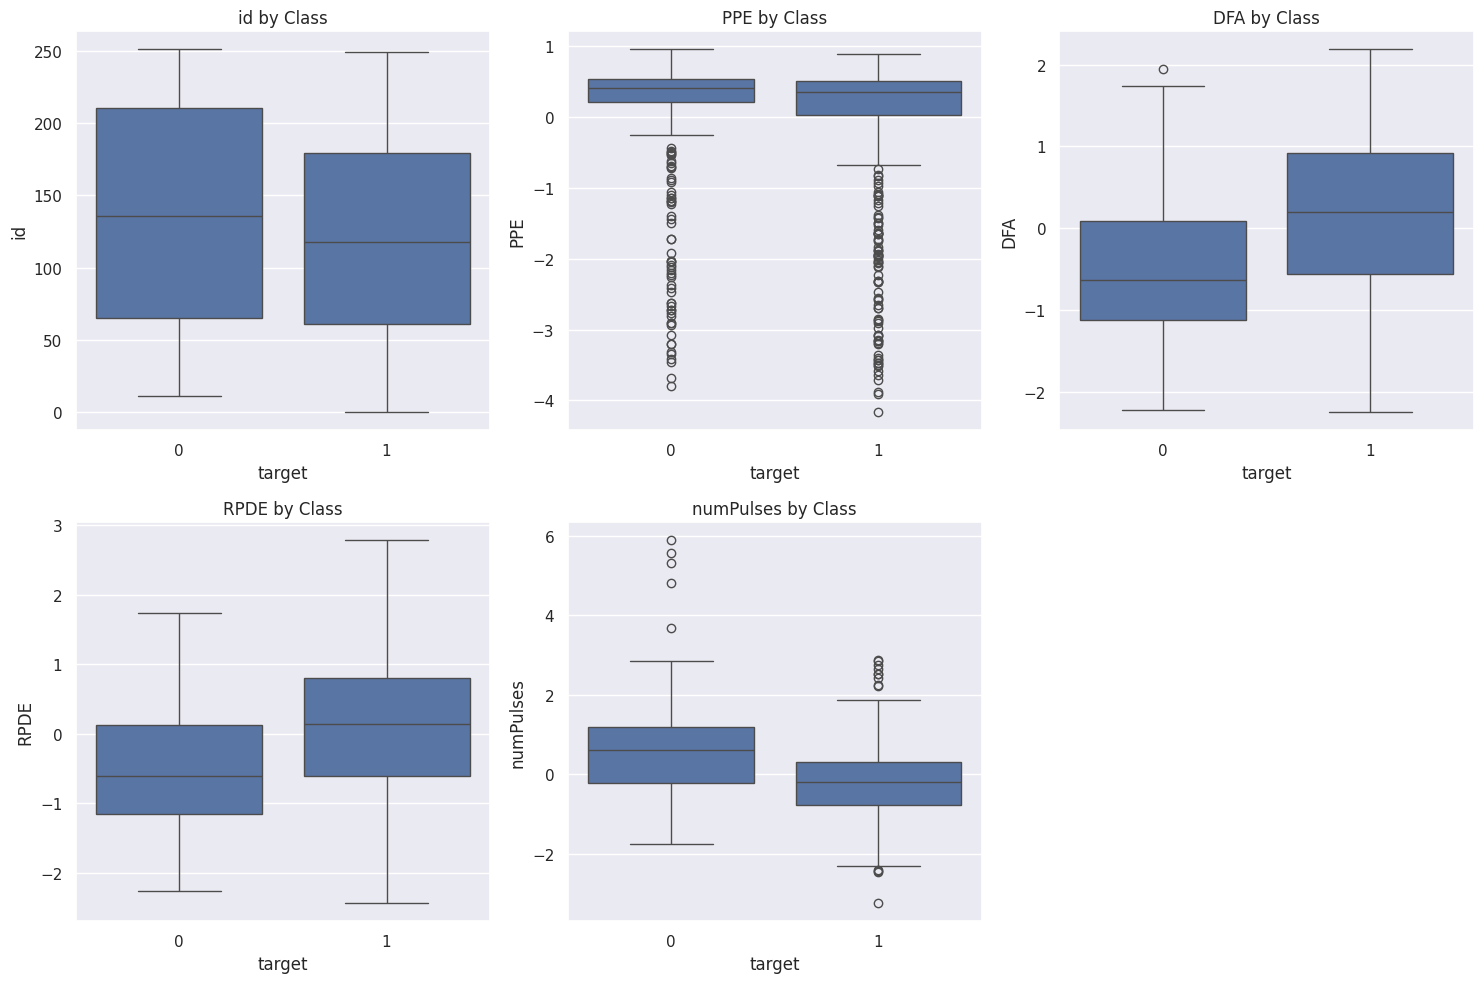

In [18]:
plt.figure(figsize=(15, 10))
for i, feature in enumerate(plot_features_list):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x='target', y=feature, data=df_eda)
    plt.title(f'{feature} by Class')
plt.tight_layout()
plt.show()

Clearly, PPE and numPulses have outliers present in their distribution, which could also be speculated from the fact that both these features have a skewed distribution.

## EDA on Voice Features

The dataset contains several voice features including jitter, shimmer, harmonicity, etc. Let us visualize trends and distribution for the voice features by class (target) using histogram and boxplots.

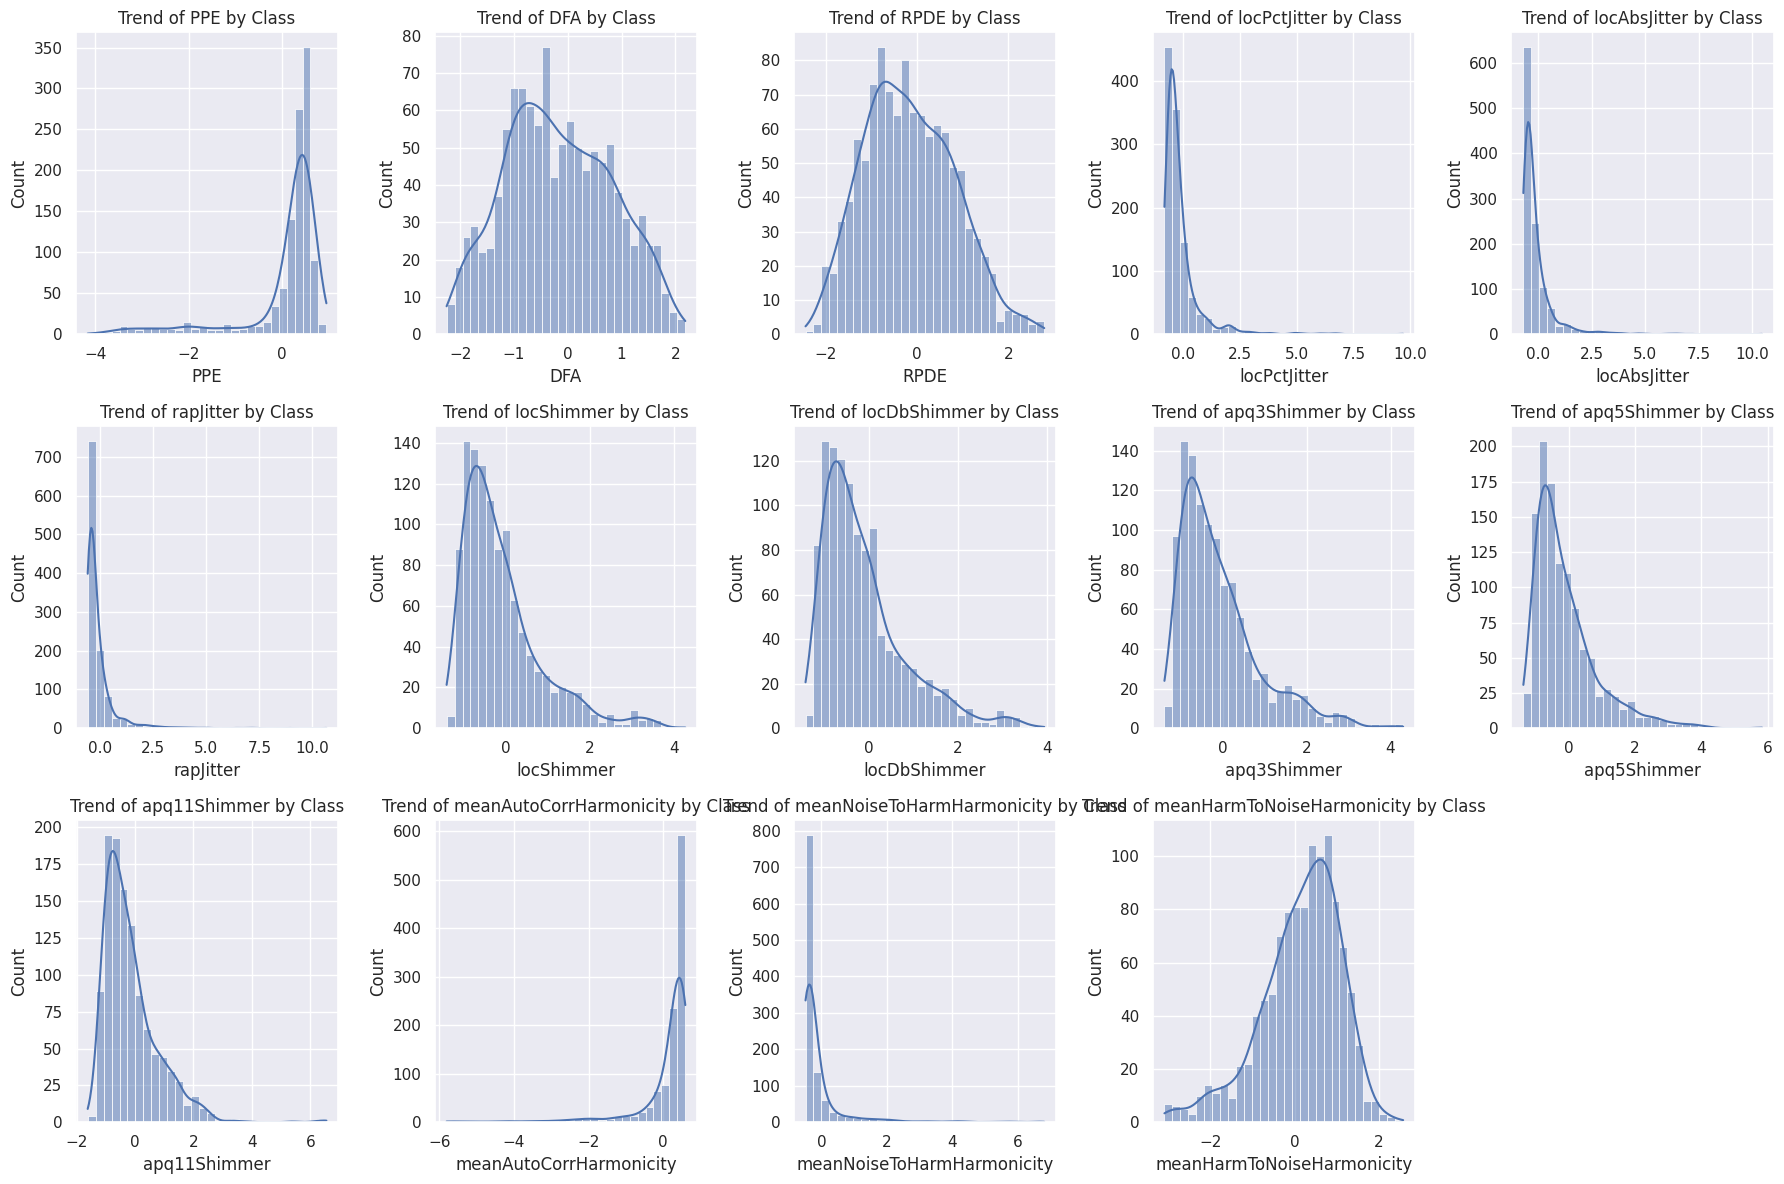

In [19]:
voice_features = ['PPE', 'DFA', 'RPDE', 'locPctJitter', 'locAbsJitter', 'rapJitter',
                  'locShimmer', 'locDbShimmer', 'apq3Shimmer', 'apq5Shimmer', 'apq11Shimmer',
                  'meanAutoCorrHarmonicity', 'meanNoiseToHarmHarmonicity', 'meanHarmToNoiseHarmonicity']

plt.figure(figsize=(18, 12))
for i, feature in enumerate(voice_features):
    if feature in df_eda.columns:
        plt.subplot(3, 5, i + 1)
        sns.histplot(df_eda[feature], kde=True, bins=30)
        plt.title(f'Trend of {feature} by Class')
plt.tight_layout()
plt.show()

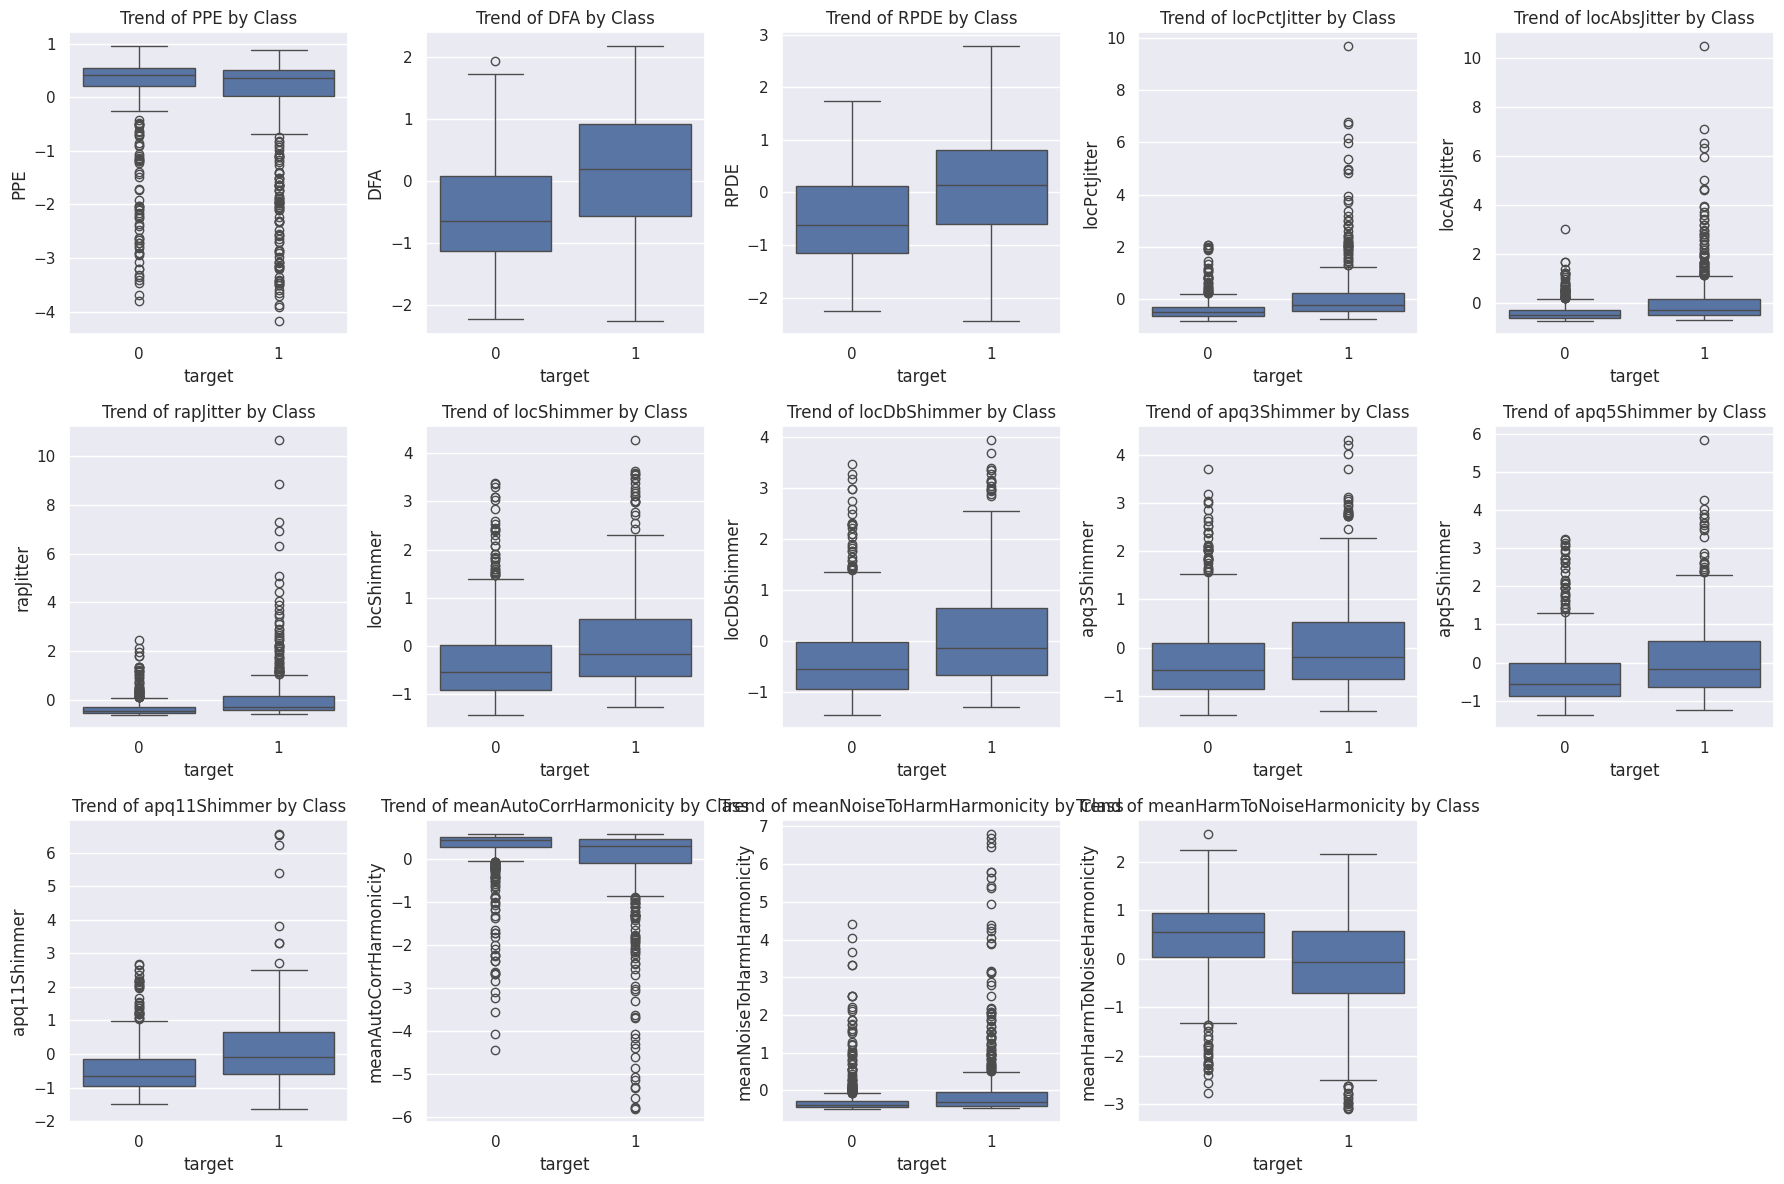

In [20]:
# Plotting trend of voice features by class (target)
plt.figure(figsize=(18, 12))
for i, feature in enumerate(voice_features):
    if feature in df_eda.columns:
        plt.subplot(3, 5, i + 1)
        sns.boxplot(x='target', y=feature, data=df_eda)
        plt.title(f'Trend of {feature} by Class')
plt.tight_layout()
plt.show()

# Model Training and Selection

Now that we have preprocessed the data, and split the data into train and test datasets, we shall now build several classification models on the training dataset and evaluate its performance on both the training and test dataset. However, we will only select that one model which performs best on the test dataset.

The various machine learning models we will be training include:
- Logistic Regression
- Random Forest
- Support Vector Machine (SVM)
- XGBoost (Extreme Gradient Boosting)

## Logistic Regression

We shall first train the model using logistic regression. Since this is a binary classification problem, logistic regression is a good starting point to train our model.

In [21]:
# importing the relevant APIs from sklearn
from sklearn.linear_model import LogisticRegression

# Creating an instance of LogisticRegression
lr = LogisticRegression(max_iter=1000, random_state=42)

#Training the model on X_train
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [22]:
lr.score(X_train, y_train)

1.0

In [23]:
lr.score(X_test, y_test)

0.8938053097345132

The score method on the `LogisticRegression` object gives us the accuracy score of the model. Clearly, the accuracy score for the training dataset is 100. For the test dataset, the accuracy score is approximately 90.7%, which is a good accuracy score. Let us now train other models and see if they perform better on the test dataset. We will then evaluate the model using other metrics such as precision, recall, and F1-score.

## Random Forest

In [24]:
# importing the relevant APIs from sklearn
from sklearn.ensemble import RandomForestClassifier

# Creating an instance of the model
rfc = RandomForestClassifier(random_state=42)

# Training the model on the training data
rfc.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
rfc.score(X_train, y_train)

1.0

In [26]:
rfc.score(X_test, y_test)

0.9247787610619469

The random forest model again gives an accuracy of 100% on the training dataset, but gives an accuracy of approximately 92.48% on the test dataset. This means that the random forest model performs better than the logistic regression model in making predictions on unseen data (since the accuracy of the logistic regression model was about 90.7%).

## Support Vector Machine (SVM)

In [27]:
# importing the relevant APIs from sklearn
from sklearn.svm import SVC

# Creating an instance of the model
svc = SVC(random_state=42)

# Training the model on the training data
svc.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [28]:
svc.score(X_train, y_train)

0.7893569844789357

In [29]:
svc.score(X_test, y_test)

0.7743362831858407

Using support vector machines (SVM), the accuracy on the training set and test set are approximately 79.16% and 74.78% respectively. This shows that they perform worse than logistic regression and random forest models on both the training and test datasets.

## XGBoost (Extreme Gradient Boosting)

In [30]:
# importing the relevant APIs from sklearn
from xgboost import XGBClassifier

# Creating an instance of the model
xgbc = XGBClassifier(random_state=42)

# Training the model on the training data
xgbc.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [31]:
xgbc.score(X_train, y_train)

1.0

In [32]:
xgbc.score(X_test, y_test)

0.9292035398230089

We can clearly tell that among all the previous models we have trained so far, XGBoost model performs best on the training set in terms of accuracy.

## Comparing Model Performance

We have already compared the model performance using the accuracy score, and figured out the the best accuracy score on the test dataset is given by the XGBoost model.

Now we shall evaluate the models based on other classification metrics such as precision, recall and F1-score. In order to do so, let us make predictions using the four models we have trained on the test dataset. This will be useful to compute the remaining evaluation metrics.

In [33]:
# Making predictions on the test dataset using logistic regression
y_pred_lr = lr.predict(X_test)

# Making predictions on the test dataset using random forest
y_pred_rfc = rfc.predict(X_test)

# Making predictions on the test dataset using SVM
y_pred_svc = svc.predict(X_test)

# Making predictions on the test dataset using XGBoost
y_pred_xgbc = xgbc.predict(X_test)

### Precision, Recall and F1-score

Qualitatively speaking, precision is the ability of a classifier to not label a sample as positive that is negative. Recall is the ability of the classifier to find all positive samples. It can be quantitatively be determined using a confusion matrix. F1-score is the harmonic mean of precision and recall scores.

Presently, we can use `precision_score`, `recall_score` and `f1_score` functions from the Scikit-Learn library to compute the precision, recall and F1 scores respectively.

#### Precision

In [34]:
# importing the relevant function to calculate precision score
from sklearn.metrics import precision_score

In [35]:
# Evaluating precision for logistic regression
precision_score(y_test, y_pred_lr)

0.979381443298969

In [36]:
# Evaluating precision for random forest
precision_score(y_test, y_pred_rfc)

0.9464285714285714

In [37]:
# Evaluating precision for SVM
precision_score(y_test, y_pred_svc)

0.8055555555555556

In [38]:
# Evaluating precision for XGBoost
precision_score(y_test, y_pred_xgbc)

0.954954954954955

#### Recall

In [39]:
# Importing the relevant function to calculate the recall score
from sklearn.metrics import recall_score

In [40]:
# Evaluating the recall score for the logistic regression model
recall_score(y_test, y_pred_lr)

0.811965811965812

In [41]:
# Evaluating the recall score for the random forest model
recall_score(y_test, y_pred_rfc)

0.905982905982906

In [42]:
# Evaluating the recall score for the SVM model
recall_score(y_test, y_pred_svc)

0.7435897435897436

In [43]:
# Evaluating the recall score for the XGBoost model
recall_score(y_test, y_pred_xgbc)

0.905982905982906

#### F1 Score

In [44]:
# Importing the relevant function to calculate the F1-score
from sklearn.metrics import f1_score

In [45]:
# Evaluating the F1-score for logistic regression
f1_score(y_test, y_pred_lr)

0.8878504672897196

In [46]:
# Evaluating the F1-score for random forest
f1_score(y_test, y_pred_rfc)

0.925764192139738

In [47]:
# Evaluating the F1-score for SVM
f1_score(y_test, y_pred_svc)

0.7733333333333333

In [48]:
# Evaluating the F1-score for XGBoost
f1_score(y_test, y_pred_xgbc)

0.9298245614035088

Clearly, the XGBoost model gives the best F1-score among the four trained models, followed by the random forest model. SVM gives the lowest F1-score among all the models we have trained.

# Model Evaluation

Based on the evaluation metrics we have discussed, we can safely select the XGBoost model for making predictions on unseen data, based on its accuracy, recall and F1-score on the test dataset.We shall now use ROC-AUC curves to assess model performance.

### ROC Curve (Receiver Operating Characteristic Curve)
The **ROC curve** is a graphical representation of the performance of a binary classification model. It plots the **True Positive Rate (TPR)** against the **False Positive Rate (FPR)** at various threshold values. 

- **True Positive Rate (TPR)**, also known as **Sensitivity** or **Recall**, is the proportion of actual positives correctly identified by the model.
  
  $$
  TPR = \frac{TP}{TP + FN}
  $$

- **False Positive Rate (FPR)** is the proportion of actual negatives incorrectly classified as positives.

  $$
  FPR = \frac{FP}{FP + TN}
  $$
Where $TP$, $FP$, $TN$ and $FN$ indicate the number of true positives, false positives, true negatives and false negatives respectively.

The ROC curve helps to visualize the trade-off between sensitivity (true positive rate) and specificity (1 - false positive rate). As the threshold changes, the TPR and FPR will change, resulting in a curve that shows how well the model performs across all possible thresholds.

### AUC (Area Under the Curve)
The **AUC** stands for **Area Under the ROC Curve**. It is a scalar value between 0 and 1 that quantifies the overall ability of the model to distinguish between positive and negative classes. 

- **AUC = 1** indicates a perfect classifier.
- **AUC = 0.5** indicates a model with no discrimination ability (i.e., random guessing).
- **AUC < 0.5** indicates a model that performs worse than random guessing.

In general, a higher AUC value implies better model performance, as it reflects a model's ability to rank positive instances higher than negative ones across all thresholds.

### Why ROC and AUC Are Useful in Classification
The ROC curve is particularly useful when the classes are imbalanced (i.e., when one class is more frequent than the other). Since the ROC curve is based on the true positive rate and false positive rate, it doesn't rely on the class distribution, making it a robust evaluation tool.

AUC, as a summary statistic, provides a single number to compare multiple models, offering insight into their overall performance. It is especially helpful when comparing models on datasets with imbalanced classes or varying decision thresholds.


0.9300556731749393


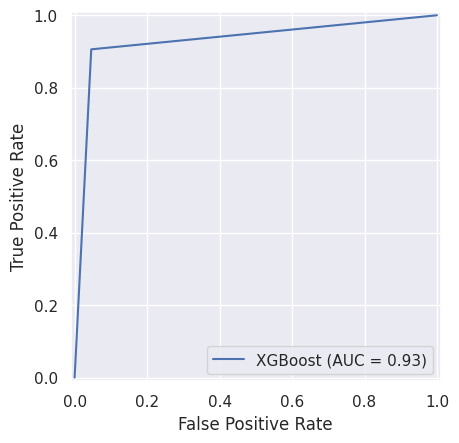

In [49]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

# Calculate ROC curve for XGBoost
fpr, tpr, thresholds = roc_curve(y_test, y_pred_xgbc)
roc_auc = auc(fpr, tpr)
print(roc_auc)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, name='XGBoost')
display.plot()
plt.show()

For the sake of completeness, we shall calculate the ROC curve for the other three models we have trained, and calculate the AUC for the same.

0.8968085940563004


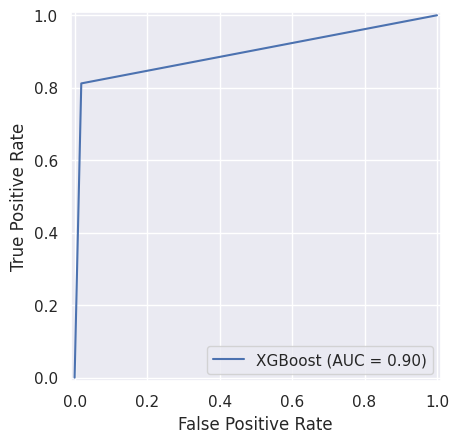

In [50]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

# Calculate ROC curve for logistic regression
fpr, tpr, thresholds = roc_curve(y_test, y_pred_lr)
roc_auc = auc(fpr, tpr)
print(roc_auc)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, name='XGBoost')
display.plot()
plt.show()

0.9254685172116364


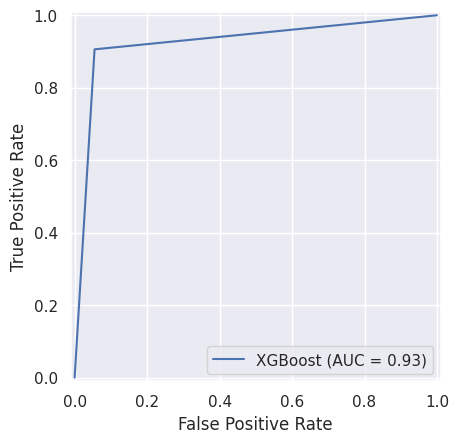

In [51]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

# Calculate ROC curve for random forest
fpr, tpr, thresholds = roc_curve(y_test, y_pred_rfc)
roc_auc = auc(fpr, tpr)
print(roc_auc)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, name='XGBoost')
display.plot()
plt.show()

0.775464596565514


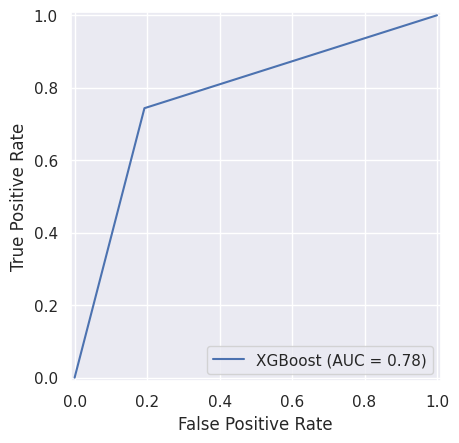

In [52]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

# Calculate ROC curve for SVM
fpr, tpr, thresholds = roc_curve(y_test, y_pred_svc)
roc_auc = auc(fpr, tpr)
print(roc_auc)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, name='XGBoost')
display.plot()
plt.show()

Clearly, all the models have AUC > 0.5, which means that their predictions are better than a random guess. The highest AUC value belongs to the XGBoost model, and the lowest to the SVM model.

# Conclusion

We built a model using a dataset which was imbalanced at first. To address this imbalance, we applied SMOTE (Synthetic Minority Over-
sampling Technique) during the data preprocessing step. 